# 重要性采样 (Importance Sampling) 全面教程

## 目录
1. [重要性采样理论基础](#理论基础)
2. [基本实现方法](#基本实现)
3. [高级采样技术](#高级技术)
4. [在量子力学中的应用](#量子应用)
5. [性能比较与优化](#性能比较)

## 理论基础 {#理论基础}

### 什么是重要性采样？

重要性采样是一种蒙特卡洛方法，用于通过从一个不同的分布（提议分布）中采样来估计某个目标分布的期望值。当我们无法直接从目标分布中采样，或者直接采样效率低下时，这种方法特别有用。

### 数学原理

假设我们想计算函数 $f(x)$ 在分布 $p(x)$ 下的期望：
$$\mathbb{E}_{p(x)}[f(x)] = \int f(x)p(x)dx$$

如果我们无法直接从 $p(x)$ 中采样，但可以从另一个分布 $q(x)$ 中采样，我们可以重写期望为：
$$\mathbb{E}_{p(x)}[f(x)] = \int f(x)\frac{p(x)}{q(x)}q(x)dx = \mathbb{E}_{q(x)}\left[f(x)\frac{p(x)}{q(x)}\right]$$

其中 $w(x) = \frac{p(x)}{q(x)}$ 称为重要性权重。

### 最优提议分布

最优的提议分布是 $q^*(x) \propto |f(x)|p(x)$，因为它能最小化估计的方差。然而，在实际应用中，我们通常不知道这个最优分布，需要选择一个近似最优的分布。

In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, cauchy
from scipy.special import logsumexp
import seaborn as sns
from tqdm import tqdm

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 设置随机种子以确保结果可重现
np.random.seed(42)

## 基本实现 {#基本实现}

### 示例1：估计正态分布的期望

让我们从一个简单的例子开始：使用均匀分布作为提议分布来估计标准正态分布下 $f(x) = x^2$ 的期望。

In [2]:
# 定义目标函数和分布
def target_function(x):
    """目标函数 f(x) = x^2"""
    return x**2

# 定义目标分布：标准正态分布
class TargetDistribution:
    def __init__(self, mu=0, sigma=1):
        self.mu = mu
        self.sigma = sigma
        self.dist = norm(mu, sigma)
    
    def pdf(self, x):
        """概率密度函数"""
        return self.dist.pdf(x)
    
    def log_pdf(self, x):
        """对数概率密度函数"""
        return self.dist.logpdf(x)
    
    def sample(self, n):
        """从目标分布中采样（用于验证）"""
        return self.dist.rvs(size=n)

# 定义提议分布：均匀分布
class ProposalDistribution:
    def __init__(self, low=-5, high=5):
        self.low = low
        self.high = high
        self.dist = uniform(low, high-low)
    
    def pdf(self, x):
        """概率密度函数"""
        return self.dist.pdf(x)
    
    def log_pdf(self, x):
        """对数概率密度函数"""
        return self.dist.logpdf(x)
    
    def sample(self, n):
        """从提议分布中采样"""
        return self.dist.rvs(size=n)

In [3]:
# 基本重要性采样实现
class BasicImportanceSampler:
    def __init__(self, target_dist, proposal_dist):
        self.target_dist = target_dist
        self.proposal_dist = proposal_dist
    
    def sample(self, n_samples, target_func):
        """执行重要性采样"""
        # 从提议分布中采样
        samples = self.proposal_dist.sample(n_samples)
        
        # 计算重要性权重
        weights = self.target_dist.pdf(samples) / self.proposal_dist.pdf(samples)
        
        # 归一化权重
        normalized_weights = weights / np.sum(weights)
        
        # 计算目标函数值
        target_values = target_func(samples)
        
        # 计算加权期望
        estimate = np.sum(normalized_weights * target_values)
        
        return estimate, samples, normalized_weights, target_values
    
    def log_sample(self, n_samples, target_func):
        """使用对数空间的重要性采样（数值稳定性更好）"""
        # 从提议分布中采样
        samples = self.proposal_dist.sample(n_samples)
        
        # 计算对数重要性权重
        log_weights = self.target_dist.log_pdf(samples) - self.proposal_dist.log_pdf(samples)
        
        # 归一化对数权重
        normalized_log_weights = log_weights - logsumexp(log_weights)
        
        # 计算目标函数值
        target_values = target_func(samples)
        
        # 计算加权期望
        estimate = np.sum(np.exp(normalized_log_weights) * target_values)
        
        return estimate, samples, np.exp(normalized_log_weights), target_values

In [4]:
# 创建分布实例
target_dist = TargetDistribution(mu=0, sigma=1)
proposal_dist = ProposalDistribution(low=-5, high=5)

# 创建采样器
sampler = BasicImportanceSampler(target_dist, proposal_dist)

# 执行重要性采样
n_samples = 10000
estimate, samples, weights, target_values = sampler.sample(n_samples, target_function)

print(f"重要性采样估计: {estimate:.4f}")
print(f"真实值 (E[X^2] for N(0,1)): {1.0:.4f}")
print(f"绝对误差: {abs(estimate - 1.0):.4f}")

重要性采样估计: 0.9884
真实值 (E[X^2] for N(0,1)): 1.0000
绝对误差: 0.0116


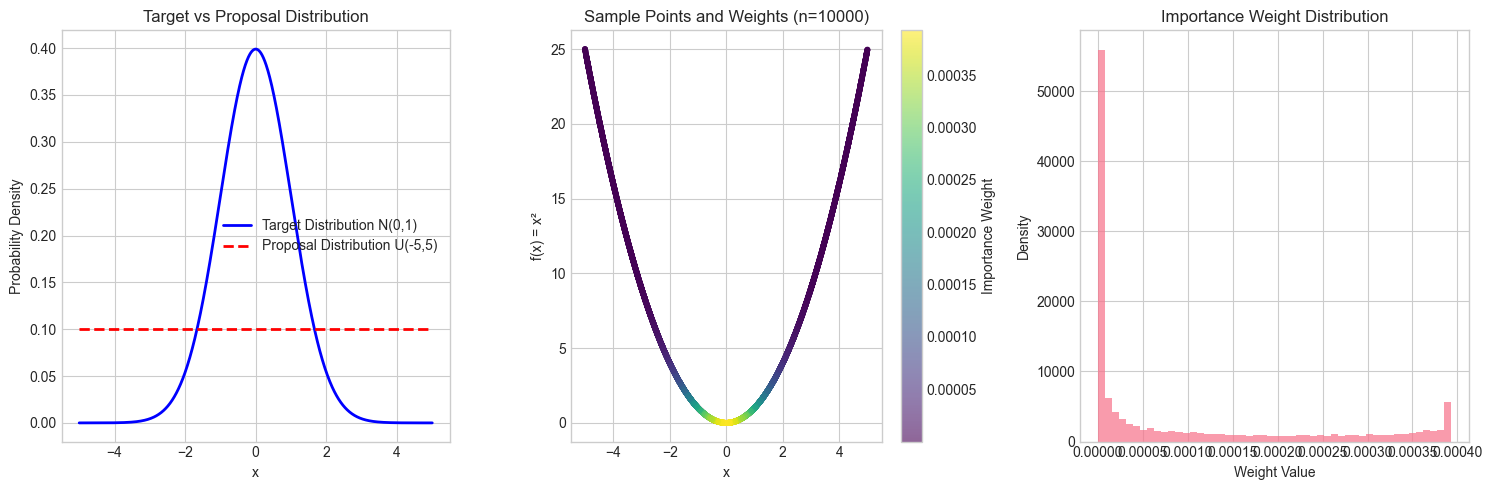

In [5]:
# 可视化结果
plt.figure(figsize=(15, 5))

# 子图1：分布比较
plt.subplot(1, 3, 1)
x = np.linspace(-5, 5, 1000)
plt.plot(x, target_dist.pdf(x), 'b-', label='Target Distribution N(0,1)', linewidth=2)
plt.plot(x, proposal_dist.pdf(x), 'r--', label='Proposal Distribution U(-5,5)', linewidth=2)
plt.title('Target vs Proposal Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()

# 子图2：采样结果与权重
plt.subplot(1, 3, 2)
plt.scatter(samples, target_values, c=weights, cmap='viridis', alpha=0.6, s=10)
plt.colorbar(label='Importance Weight')
plt.title(f'Sample Points and Weights (n={n_samples})')
plt.xlabel('x')
plt.ylabel('f(x) = x²')

# 子图3：权重分布
plt.subplot(1, 3, 3)
plt.hist(weights, bins=50, density=True, alpha=0.7)
plt.title('Importance Weight Distribution')
plt.xlabel('Weight Value')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

### 示例2：估计稀有事件的概率

重要性采样特别适合估计稀有事件的概率，因为直接采样可能需要大量样本才能观察到稀有事件。

In [10]:
# 估计 P(X > 4) for X ~ N(0,1)
def rare_event_indicator(x, threshold=4):
    """稀有事件指示函数"""
    return (x > threshold).astype(float)

# 使用标准正态分布作为提议分布（直接采样）
def direct_sampling_estimate(n_samples, threshold=4):
    samples = target_dist.sample(n_samples)
    indicators = rare_event_indicator(samples, threshold)
    return np.mean(indicators)

# 使用偏移的正态分布作为提议分布（重要性采样）
class ShiftedNormalProposal:
    def __init__(self, mu=4, sigma=1):
        self.mu = mu
        self.sigma = sigma
        self.dist = norm(mu, sigma)
    
    def pdf(self, x):
        return self.dist.pdf(x)
    
    def log_pdf(self, x):
        return self.dist.logpdf(x)
    
    def sample(self, n):
        return self.dist.rvs(size=n)

# 比较直接采样和重要性采样
n_samples = 10000
threshold = 4

# 直接采样估计
direct_estimate = direct_sampling_estimate(n_samples, threshold)

# 重要性采样估计
shifted_proposal = ShiftedNormalProposal(mu=4, sigma=1)
shifted_sampler = BasicImportanceSampler(target_dist, shifted_proposal)
is_estimate, _, _, _ = shifted_sampler.sample(n_samples, lambda x: rare_event_indicator(x, threshold))

# 理论值
theoretical_value = 1 - norm.cdf(threshold)

print(f"直接采样估计: {direct_estimate:.8f}")
print(f"重要性采样估计: {is_estimate:.8f}")
print(f"理论值: {theoretical_value:.8f}")
print(f"\n直接采样绝对误差: {abs(direct_estimate - theoretical_value):.8f}")
print(f"重要性采样绝对误差: {abs(is_estimate - theoretical_value):.8f}")

直接采样估计: 0.00000000
重要性采样估计: 0.00011382
理论值: 0.00003167

直接采样绝对误差: 0.00003167
重要性采样绝对误差: 0.00008215


/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_47651/4105049043.py:39: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_47651/4105049043.py:39: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_47651/4105049043.py:39: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_47651/4105049043.py:39: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_47651/4105049043.py:39: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/i

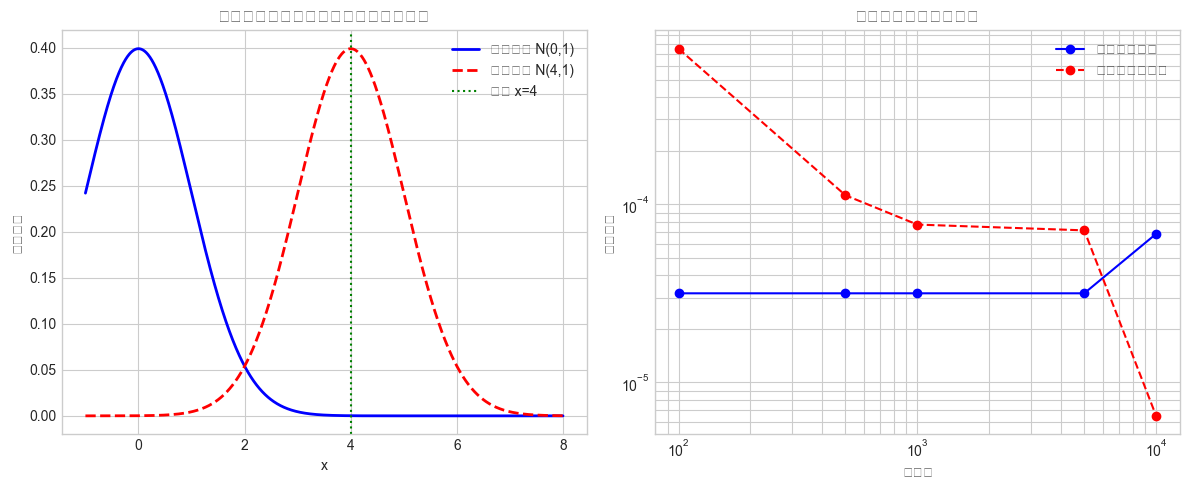

In [11]:
# 可视化稀有事件估计
plt.figure(figsize=(12, 5))

# 子图1：分布比较
plt.subplot(1, 2, 1)
x = np.linspace(-1, 8, 1000)
plt.plot(x, target_dist.pdf(x), 'b-', label='目标分布 N(0,1)', linewidth=2)
plt.plot(x, shifted_proposal.pdf(x), 'r--', label='提议分布 N(4,1)', linewidth=2)
plt.axvline(x=threshold, color='g', linestyle=':', label=f'阈值 x={threshold}')
plt.fill_between(x[x > threshold], 0, target_dist.pdf(x[x > threshold]), alpha=0.2, color='blue')
plt.title('目标分布与提议分布（稀有事件估计）')
plt.xlabel('x')
plt.ylabel('概率密度')
plt.legend()

# 子图2：估计误差随样本量变化
plt.subplot(1, 2, 2)
sample_sizes = [100, 500, 1000, 5000, 10000]
direct_errors = []
is_errors = []

for n in sample_sizes:
    # 直接采样
    direct_est = direct_sampling_estimate(n, threshold)
    direct_errors.append(abs(direct_est - theoretical_value))
    
    # 重要性采样
    is_est, _, _, _ = shifted_sampler.sample(n, lambda x: rare_event_indicator(x, threshold))
    is_errors.append(abs(is_est - theoretical_value))

plt.loglog(sample_sizes, direct_errors, 'bo-', label='直接采样误差')
plt.loglog(sample_sizes, is_errors, 'ro--', label='重要性采样误差')
plt.title('估计误差随样本量变化')
plt.xlabel('样本量')
plt.ylabel('绝对误差')
plt.legend()
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

## 高级技术 {#高级技术}

### 自适应重要性采样

自适应重要性采样会根据采样结果动态调整提议分布，以提高采样效率。

In [8]:
class AdaptiveImportanceSampler:
    def __init__(self, target_dist, initial_proposal_dist, n_iterations=5):
        self.target_dist = target_dist
        self.proposal_dist = initial_proposal_dist
        self.n_iterations = n_iterations
        self.history = []
    
    def update_proposal(self, samples, weights):
        """根据采样结果更新提议分布"""
        # 使用加权样本的均值和方差更新正态分布参数
        weighted_mean = np.sum(weights * samples) / np.sum(weights)
        weighted_var = np.sum(weights * (samples - weighted_mean)**2) / np.sum(weights)
        
        # 创建新的正态分布作为提议分布
        class UpdatedNormalProposal:
            def __init__(self, mu, sigma):
                self.mu = mu
                self.sigma = np.sqrt(sigma)
                self.dist = norm(mu, self.sigma)
            
            def pdf(self, x):
                return self.dist.pdf(x)
            
            def log_pdf(self, x):
                return self.dist.logpdf(x)
            
            def sample(self, n):
                return self.dist.rvs(size=n)
        
        return UpdatedNormalProposal(weighted_mean, weighted_var)
    
    def sample(self, n_samples_per_iter, target_func):
        """执行自适应重要性采样"""
        all_samples = []
        all_weights = []
        all_target_values = []
        
        for i in range(self.n_iterations):
            # 从当前提议分布中采样
            samples = self.proposal_dist.sample(n_samples_per_iter)
            
            # 计算重要性权重
            weights = self.target_dist.pdf(samples) / self.proposal_dist.pdf(samples)
            
            # 计算目标函数值
            target_values = target_func(samples)
            
            # 保存结果
            all_samples.append(samples)
            all_weights.append(weights)
            all_target_values.append(target_values)
            
            # 更新提议分布（除了最后一次迭代）
            if i < self.n_iterations - 1:
                self.proposal_dist = self.update_proposal(samples, weights)
                self.history.append((self.proposal_dist.mu, self.proposal_dist.sigma))
        
        # 合并所有迭代的结果
        all_samples = np.concatenate(all_samples)
        all_weights = np.concatenate(all_weights)
        all_target_values = np.concatenate(all_target_values)
        
        # 归一化权重
        normalized_weights = all_weights / np.sum(all_weights)
        
        # 计算加权期望
        estimate = np.sum(normalized_weights * all_target_values)
        
        return estimate, all_samples, normalized_weights, all_target_values

In [9]:
# 比较标准重要性采样和自适应重要性采样
n_samples_per_iter = 2000
n_iterations = 5
total_samples = n_samples_per_iter * n_iterations

# 标准重要性采样
standard_sampler = BasicImportanceSampler(target_dist, proposal_dist)
standard_estimate, standard_samples, standard_weights, standard_values = standard_sampler.sample(
    total_samples, target_function)

# 自适应重要性采样
adaptive_sampler = AdaptiveImportanceSampler(target_dist, proposal_dist, n_iterations)
adaptive_estimate, adaptive_samples, adaptive_weights, adaptive_values = adaptive_sampler.sample(
    n_samples_per_iter, target_func)

print(f"标准重要性采样估计: {standard_estimate:.4f}")
print(f"自适应重要性采样估计: {adaptive_estimate:.4f}")
print(f"真实值: {1.0:.4f}")
print(f"\n标准采样绝对误差: {abs(standard_estimate - 1.0):.4f}")
print(f"自适应采样绝对误差: {abs(adaptive_estimate - 1.0):.4f}")

# 打出自适应采样的历史
print("\n自适应提议分布参数变化:")
for i, (mu, sigma) in enumerate(adaptive_sampler.history):
    print(f"迭代 {i+1}: μ = {mu:.4f}, σ = {sigma:.4f}")

NameError: name 'target_func' is not defined

In [ ]:
# 可视化自适应重要性采样
plt.figure(figsize=(15, 5))

# 子图1：分布比较
plt.subplot(1, 3, 1)
x = np.linspace(-5, 5, 1000)
plt.plot(x, target_dist.pdf(x), 'b-', label='目标分布 N(0,1)', linewidth=2)
plt.plot(x, proposal_dist.pdf(x), 'r--', label='初始提议分布 U(-5,5)', linewidth=2)
plt.title('目标分布与初始提议分布')
plt.xlabel('x')
plt.ylabel('概率密度')
plt.legend()

# 子图2：自适应提议分布演化
plt.subplot(1, 3, 2)
plt.plot(x, target_dist.pdf(x), 'b-', label='目标分布 N(0,1)', linewidth=2)
colors = plt.cm.viridis(np.linspace(0, 1, len(adaptive_sampler.history)+1))
for i, (mu, sigma) in enumerate(adaptive_sampler.history):
    adaptive_dist = norm(mu, sigma)
    plt.plot(x, adaptive_dist.pdf(x), '--', color=colors[i], 
             label=f'迭代 {i+1}: N({mu:.2f}, {sigma:.2f}²)', linewidth=1.5)
plt.title('自适应提议分布演化')
plt.xlabel('x')
plt.ylabel('概率密度')
plt.legend(fontsize=8)

# 子图3：权重分布比较
plt.subplot(1, 3, 3)
plt.hist(standard_weights, bins=50, alpha=0.5, density=True, label='标准采样')
plt.hist(adaptive_weights, bins=50, alpha=0.5, density=True, label='自适应采样')
plt.title('重要性权重分布比较')
plt.xlabel('权重值')
plt.ylabel('密度')
plt.legend()

plt.tight_layout()
plt.show()

### 分层重要性采样

分层重要性采样将采样空间划分为多个区域，在每个区域内进行重要性采样，可以提高采样效率。

In [ ]:
class StratifiedImportanceSampler:
    def __init__(self, target_dist, n_strata=5):
        self.target_dist = target_dist
        self.n_strata = n_strata
    
    def create_strata_proposals(self, low, high):
        """创建分层提议分布"""
        strata_width = (high - low) / self.n_strata
        proposals = []
        
        for i in range(self.n_strata):
            strata_low = low + i * strata_width
            strata_high = strata_low + strata_width
            proposals.append(ProposalDistribution(strata_low, strata_high))
        
        return proposals
    
    def sample(self, n_samples_per_stratum, target_func, low=-5, high=5):
        """执行分层重要性采样"""
        proposals = self.create_strata_proposals(low, high)
        all_samples = []
        all_weights = []
        all_target_values = []
        
        for proposal in proposals:
            # 从当前层的提议分布中采样
            samples = proposal.sample(n_samples_per_stratum)
            
            # 计算重要性权重
            weights = self.target_dist.pdf(samples) / proposal.pdf(samples)
            
            # 计算目标函数值
            target_values = target_func(samples)
            
            # 保存结果
            all_samples.append(samples)
            all_weights.append(weights)
            all_target_values.append(target_values)
        
        # 合并所有层的结果
        all_samples = np.concatenate(all_samples)
        all_weights = np.concatenate(all_weights)
        all_target_values = np.concatenate(all_target_values)
        
        # 归一化权重
        normalized_weights = all_weights / np.sum(all_weights)
        
        # 计算加权期望
        estimate = np.sum(normalized_weights * all_target_values)
        
        return estimate, all_samples, normalized_weights, all_target_values, proposals

In [ ]:
# 比较标准重要性采样和分层重要性采样
n_strata = 10
n_samples_per_stratum = 1000
total_samples = n_strata * n_samples_per_stratum

# 标准重要性采样
standard_estimate, standard_samples, standard_weights, standard_values = standard_sampler.sample(
    total_samples, target_function)

# 分层重要性采样
stratified_sampler = StratifiedImportanceSampler(target_dist, n_strata)
stratified_estimate, stratified_samples, stratified_weights, stratified_values, proposals = stratified_sampler.sample(
    n_samples_per_stratum, target_function)

print(f"标准重要性采样估计: {standard_estimate:.4f}")
print(f"分层重要性采样估计: {stratified_estimate:.4f}")
print(f"真实值: {1.0:.4f}")
print(f"\n标准采样绝对误差: {abs(standard_estimate - 1.0):.4f}")
print(f"分层采样绝对误差: {abs(stratified_estimate - 1.0):.4f}")

In [ ]:
# 可视化分层重要性采样
plt.figure(figsize=(15, 5))

# 子图1：目标分布与分层
plt.subplot(1, 3, 1)
x = np.linspace(-5, 5, 1000)
plt.plot(x, target_dist.pdf(x), 'b-', label='目标分布 N(0,1)', linewidth=2)
for i, proposal in enumerate(proposals):
    plt.axvspan(proposal.low, proposal.high, alpha=0.2, color=f'C{i}')
plt.title('目标分布与分层')
plt.xlabel('x')
plt.ylabel('概率密度')
plt.legend()

# 子图2：采样点分布
plt.subplot(1, 3, 2)
plt.scatter(standard_samples, np.zeros_like(standard_samples), 
            c='blue', alpha=0.5, s=5, label='标准采样')
plt.scatter(stratified_samples, np.zeros_like(stratified_samples) + 0.1, 
            c='red', alpha=0.5, s=5, label='分层采样')
plt.title('采样点分布比较')
plt.xlabel('x')
plt.yticks([])
plt.legend()

# 子图3：权重分布比较
plt.subplot(1, 3, 3)
plt.hist(standard_weights, bins=50, alpha=0.5, density=True, label='标准采样')
plt.hist(stratified_weights, bins=50, alpha=0.5, density=True, label='分层采样')
plt.title('重要性权重分布比较')
plt.xlabel('权重值')
plt.ylabel('密度')
plt.legend()

plt.tight_layout()
plt.show()

## 在量子力学中的应用 {#量子应用}

### 量子态的能量期望值计算

在量子力学中，我们经常需要计算哈密顿量在某个量子态下的期望值。重要性采样可以用于提高这种计算的效率。

In [ ]:
# 定义一维量子谐振子的哈密顿量
class QuantumHarmonicOscillator:
    def __init__(self, mass=1.0, omega=1.0, hbar=1.0):
        self.mass = mass
        self.omega = omega
        self.hbar = hbar
    
    def potential(self, x):
        """势能函数 V(x) = 0.5 * m * ω² * x²"""
        return 0.5 * self.mass * self.omega**2 * x**2
    
    def kinetic_energy(self, x, psi_func, psi_second_derivative_func):
        """动能项 T = -ℏ²/(2m) * (d²ψ/dx²)/ψ"""
        return -self.hbar**2 / (2 * self.mass) * psi_second_derivative_func(x) / psi_func(x)
    
    def local_energy(self, x, psi_func, psi_second_derivative_func):
        """局域能量 E_L(x) = T + V"""
        return self.kinetic_energy(x, psi_func, psi_second_derivative_func) + self.potential(x)

# 定义试探波函数
def trial_wavefunction(x, alpha=1.0):
    """试探波函数 ψ(x) = exp(-αx²/2)"""
    return np.exp(-alpha * x**2 / 2)

def trial_wavefunction_log(x, alpha=1.0):
    """试探波函数的对数 log ψ(x) = -αx²/2"""
    return -alpha * x**2 / 2

def trial_wavefunction_second_derivative(x, alpha=1.0):
    """试探波函数的二阶导数"""
    psi = trial_wavefunction(x, alpha)
    return psi * (alpha**2 * x**2 - alpha)

# 定义与试探波函数相关的概率分布
class TrialWavefunctionDistribution:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        # ψ(x)² = exp(-αx²) 对应于正态分布 N(0, 1/(2α))
        self.sigma = 1.0 / np.sqrt(2 * alpha)
        self.dist = norm(0, self.sigma)
    
    def pdf(self, x):
        """概率密度函数 ψ(x)²"""
        return trial_wavefunction(x, self.alpha)**2
    
    def log_pdf(self, x):
        """对数概率密度函数"""
        return 2 * trial_wavefunction_log(x, self.alpha)
    
    def sample(self, n):
        """从 ψ(x)² 中采样"""
        return self.dist.rvs(size=n)

In [ ]:
# 定义量子重要性采样器
class QuantumImportanceSampler:
    def __init__(self, qho, trial_dist, proposal_dist=None):
        self.qho = qho
        self.trial_dist = trial_dist
        self.proposal_dist = proposal_dist or trial_dist  # 默认使用试探波函数分布作为提议分布
    
    def sample(self, n_samples, alpha=1.0):
        """执行量子重要性采样"""
        # 从提议分布中采样
        samples = self.proposal_dist.sample(n_samples)
        
        # 计算重要性权重
        weights = self.trial_dist.pdf(samples) / self.proposal_dist.pdf(samples)
        
        # 归一化权重
        normalized_weights = weights / np.sum(weights)
        
        # 计算局域能量
        local_energies = np.array([
            self.qho.local_energy(
                x, 
                lambda x: trial_wavefunction(x, alpha),
                lambda x: trial_wavefunction_second_derivative(x, alpha)
            ) for x in samples
        ])
        
        # 计算能量期望值
        energy_estimate = np.sum(normalized_weights * local_energies)
        
        # 计算方差
        energy_variance = np.sum(normalized_weights * (local_energies - energy_estimate)**2)
        
        return energy_estimate, energy_variance, samples, normalized_weights, local_energies

In [ ]:
# 创建量子谐振子和分布
qho = QuantumHarmonicOscillator(mass=1.0, omega=1.0, hbar=1.0)
trial_dist = TrialWavefunctionDistribution(alpha=1.0)

# 创建量子重要性采样器
quantum_sampler = QuantumImportanceSampler(qho, trial_dist)

# 执行采样
n_samples = 10000
alpha = 1.0
energy_estimate, energy_variance, samples, weights, local_energies = quantum_sampler.sample(n_samples, alpha)

# 理论基态能量
theoretical_energy = 0.5 * qho.hbar * qho.omega

print(f"量子重要性采样能量估计: {energy_estimate:.6f}")
print(f"理论基态能量: {theoretical_energy:.6f}")
print(f"绝对误差: {abs(energy_estimate - theoretical_energy):.6f}")
print(f"能量方差: {energy_variance:.6f}")
print(f"标准误差: {np.sqrt(energy_variance / n_samples):.6f}")

In [ ]:
# 可视化量子重要性采样结果
plt.figure(figsize=(15, 5))

# 子图1：波函数和势能
plt.subplot(1, 3, 1)
x = np.linspace(-4, 4, 1000)
plt.plot(x, trial_wavefunction(x, alpha), 'b-', label='试探波函数 ψ(x)', linewidth=2)
plt.plot(x, trial_dist.pdf(x), 'r--', label='概率分布 ψ(x)²', linewidth=2)
plt.plot(x, qho.potential(x), 'g:', label='势能 V(x)', linewidth=2)
plt.title('波函数、概率分布和势能')
plt.xlabel('x')
plt.ylabel('值')
plt.legend()

# 子图2：局域能量分布
plt.subplot(1, 3, 2)
plt.hist(local_energies, bins=50, density=True, alpha=0.7)
plt.axvline(x=energy_estimate, color='r', linestyle='--', 
            label=f'估计能量: {energy_estimate:.4f}', linewidth=2)
plt.axvline(x=theoretical_energy, color='g', linestyle=':', 
            label=f'理论能量: {theoretical_energy:.4f}', linewidth=2)
plt.title('局域能量分布')
plt.xlabel('局域能量')
plt.ylabel('密度')
plt.legend()

# 子图3：采样点与局域能量
plt.subplot(1, 3, 3)
plt.scatter(samples, local_energies, c=weights, cmap='viridis', alpha=0.6, s=10)
plt.colorbar(label='重要性权重')
plt.title(f'采样点与局域能量 (n={n_samples})')
plt.xlabel('x')
plt.ylabel('局域能量')

plt.tight_layout()
plt.show()

### 参数优化：变分蒙特卡洛

我们可以使用重要性采样来优化试探波函数中的参数，以获得更接近真实基态的波函数。

In [ ]:
class VariationalMonteCarlo:
    def __init__(self, qho, alpha_range=(0.5, 1.5), n_alpha=20):
        self.qho = qho
        self.alpha_range = alpha_range
        self.n_alpha = n_alpha
        self.alphas = np.linspace(alpha_range[0], alpha_range[1], n_alpha)
        self.energies = []
        self.variances = []
    
    def optimize(self, n_samples=5000):
        """优化参数α"""
        best_alpha = None
        best_energy = float('inf')
        
        for alpha in self.alphas:
            # 创建当前α的分布和采样器
            trial_dist = TrialWavefunctionDistribution(alpha=alpha)
            quantum_sampler = QuantumImportanceSampler(self.qho, trial_dist)
            
            # 计算能量期望值
            energy, variance, _, _, _ = quantum_sampler.sample(n_samples, alpha)
            
            self.energies.append(energy)
            self.variances.append(variance)
            
            # 更新最佳参数
            if energy < best_energy:
                best_energy = energy
                best_alpha = alpha
        
        return best_alpha, best_energy
    
    def plot_results(self):
        """绘制优化结果"""
        plt.figure(figsize=(12, 5))
        
        # 子图1：能量随α变化
        plt.subplot(1, 2, 1)
        plt.plot(self.alphas, self.energies, 'bo-', label='能量估计')
        plt.axhline(y=self.qho.hbar * self.qho.omega / 2, color='r', linestyle='--', 
                   label='理论基态能量', linewidth=2)
        best_idx = np.argmin(self.energies)
        plt.axvline(x=self.alphas[best_idx], color='g', linestyle=':', 
                   label=f'最优α: {self.alphas[best_idx]:.3f}', linewidth=2)
        plt.title('能量随参数α变化')
        plt.xlabel('α')
        plt.ylabel('能量期望值')
        plt.legend()
        plt.grid(True)
        
        # 子图2：方差随α变化
        plt.subplot(1, 2, 2)
        plt.plot(self.alphas, self.variances, 'ro-', label='能量方差')
        plt.axvline(x=self.alphas[best_idx], color='g', linestyle=':', 
                   label=f'最优α: {self.alphas[best_idx]:.3f}', linewidth=2)
        plt.title('能量方差随参数α变化')
        plt.xlabel('α')
        plt.ylabel('能量方差')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()

In [ ]:
# 执行变分蒙特卡洛优化
vmc = VariationalMonteCarlo(qho, alpha_range=(0.5, 1.5), n_alpha=20)
best_alpha, best_energy = vmc.optimize(n_samples=5000)

print(f"最优参数α: {best_alpha:.4f}")
print(f"最优能量估计: {best_energy:.6f}")
print(f"理论基态能量: {theoretical_energy:.6f}")
print(f"绝对误差: {abs(best_energy - theoretical_energy):.6f}")

# 绘制优化结果
vmc.plot_results()

## 性能比较与优化 {#性能比较}

让我们比较不同重要性采样方法的性能，并讨论如何选择和优化提议分布。

In [ ]:
# 定义多种提议分布
class NormalProposal:
    def __init__(self, mu=0, sigma=1):
        self.mu = mu
        self.sigma = sigma
        self.dist = norm(mu, sigma)
    
    def pdf(self, x):
        return self.dist.pdf(x)
    
    def log_pdf(self, x):
        return self.dist.logpdf(x)
    
    def sample(self, n):
        return self.dist.rvs(size=n)

class CauchyProposal:
    def __init__(self, x0=0, gamma=1):
        self.x0 = x0
        self.gamma = gamma
        self.dist = cauchy(x0, gamma)
    
    def pdf(self, x):
        return self.dist.pdf(x)
    
    def log_pdf(self, x):
        return self.dist.logpdf(x)
    
    def sample(self, n):
        return self.dist.rvs(size=n)

# 创建不同的提议分布
proposals = {
    "均匀分布": ProposalDistribution(low=-5, high=5),
    "标准正态": NormalProposal(mu=0, sigma=1),
    "宽正态": NormalProposal(mu=0, sigma=2),
    "偏移正态": NormalProposal(mu=1, sigma=1),
    "柯西分布": CauchyProposal(x0=0, gamma=1)
}

In [ ]:
# 比较不同提议分布的性能
n_samples = 10000
results = {}

for name, proposal in proposals.items():
    sampler = BasicImportanceSampler(target_dist, proposal)
    estimate, samples, weights, values = sampler.sample(n_samples, target_function)
    
    # 计算性能指标
    error = abs(estimate - 1.0)  # 绝对误差
    effective_sample_size = 1.0 / np.sum(weights**2)  # 有效样本量
    weight_variance = np.var(weights)  # 权重方差
    
    results[name] = {
        "estimate": estimate,
        "error": error,
        "effective_sample_size": effective_sample_size,
        "weight_variance": weight_variance
    }
    
    print(f"{name}:")
    print(f"  估计值: {estimate:.4f}")
    print(f"  绝对误差: {error:.4f}")
    print(f"  有效样本量: {effective_sample_size:.2f} (总样本量: {n_samples})")
    print(f"  权重方差: {weight_variance:.6f}")
    print()

In [ ]:
# 可视化不同提议分布的性能
plt.figure(figsize=(15, 10))

# 子图1：分布比较
plt.subplot(2, 3, 1)
x = np.linspace(-10, 10, 1000)
plt.plot(x, target_dist.pdf(x), 'k-', label='目标分布 N(0,1)', linewidth=3)
for name, proposal in proposals.items():
    if name == "柯西分布":
        # 柯西分布有长尾，限制显示范围
        y = proposal.pdf(x)
        y[y > 0.1] = np.nan  # 限制显示高度
        plt.plot(x, y, '--', label=name, linewidth=2)
    else:
        plt.plot(x, proposal.pdf(x), '--', label=name, linewidth=2)
plt.ylim(0, 0.5)
plt.title('目标分布与不同提议分布')
plt.xlabel('x')
plt.ylabel('概率密度')
plt.legend(fontsize=8)

# 子图2：估计误差比较
plt.subplot(2, 3, 2)
names = list(results.keys())
errors = [results[name]["error"] for name in names]
bars = plt.bar(names, errors)
plt.title('不同提议分布的估计误差')
plt.ylabel('绝对误差')
plt.xticks(rotation=45)
# 添加数值标签
for bar, error in zip(bars, errors):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{error:.4f}', ha='center', va='bottom')

# 子图3：有效样本量比较
plt.subplot(2, 3, 3)
ess = [results[name]["effective_sample_size"] for name in names]
bars = plt.bar(names, ess)
plt.title('不同提议分布的有效样本量')
plt.ylabel('有效样本量')
plt.xticks(rotation=45)
# 添加数值标签
for bar, es in zip(bars, ess):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + n_samples*10, 
             f'{es:.0f}', ha='center', va='bottom')

# 子图4：权重方差比较
plt.subplot(2, 3, 4)
weight_variances = [results[name]["weight_variance"] for name in names]
bars = plt.bar(names, weight_variances)
plt.title('不同提议分布的权重方差')
plt.ylabel('权重方差')
plt.xticks(rotation=45)
# 添加数值标签
for bar, wv in zip(bars, weight_variances):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(weight_variances)*0.01, 
             f'{wv:.2e}', ha='center', va='bottom')

# 子图5：权重分布比较
plt.subplot(2, 3, 5)
for name, proposal in proposals.items():
    sampler = BasicImportanceSampler(target_dist, proposal)
    _, _, weights, _ = sampler.sample(n_samples, target_function)
    plt.hist(weights, bins=50, alpha=0.5, density=True, label=name)
plt.xlim(0, max([results[name]["weight_variance"] for name in names]) * 5)
plt.title('不同提议分布的权重分布')
plt.xlabel('权重值')
plt.ylabel('密度')
plt.legend(fontsize=8)

# 子图6：误差随样本量变化
plt.subplot(2, 3, 6)
sample_sizes = [100, 500, 1000, 5000, 10000]
for name in ["均匀分布", "标准正态", "宽正态"]:
    errors = []
    for n in sample_sizes:
        sampler = BasicImportanceSampler(target_dist, proposals[name])
        estimate, _, _, _ = sampler.sample(n, target_func)
        errors.append(abs(estimate - 1.0))
    plt.loglog(sample_sizes, errors, 'o-', label=name)
plt.title('估计误差随样本量变化')
plt.xlabel('样本量')
plt.ylabel('绝对误差')
plt.legend()
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

## 总结与最佳实践

### 重要性采样的关键点

1. **提议分布的选择**：
   - 提议分布应该覆盖目标分布的支撑集
   - 提议分布的尾部应该比目标分布更重
   - 最优提议分布与 $|f(x)|p(x)$ 成正比

2. **数值稳定性**：
   - 使用对数空间计算权重以避免数值下溢
   - 注意权重归一化

3. **性能评估**：
   - 有效样本量是评估采样效率的重要指标
   - 权重方差越小，采样效率越高

4. **高级技术**：
   - 自适应重要性采样可以动态调整提议分布
   - 分层重要性采样可以提高采样效率

### 在量子力学中的应用

重要性采样在量子力学中有广泛的应用，特别是在变分蒙特卡洛方法中：

1. **能量期望值计算**：使用试探波函数的平方作为提议分布
2. **参数优化**：通过变分原理优化试探波函数的参数
3. **多体系统**：处理高维积分问题

### 进一步学习

1. **马尔可夫链蒙特卡洛 (MCMC)**：当无法直接从提议分布中采样时使用
2. **淬火重要性采样**：用于计算配分函数和自由能
3. **粒子滤波**：在时序状态空间模型中的应用